In [1]:
print("hello")

hello


In [2]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END
from typing import TypedDict

In [3]:
load_dotenv()

True

In [4]:
# MODIFY: Add new fields to state if needed
class LLMProcessingState(TypedDict):
    user_input: str
    llm_response: str
    processing_steps: list[str]
    # Add more here: timestamp, model_used, tokens_used, etc.
 
 
# MODIFY: Change node logic, add nodes, etc.
def llm_step(state: LLMProcessingState):
    """Call the LLM."""
    model = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
    message = HumanMessage(content=state["user_input"])
    response = model.invoke([message])
 
    return {
        "llm_response": response.content,
        "processing_steps": state["processing_steps"] + ["Called LLM"],
    }
 
 
def format_output(state: LLMProcessingState):
    """Format the output."""
    formatted = (
        f"User asked: {state['user_input']}\n\nLLM replied: {state['llm_response']}"
    )
    return {
        "llm_response": formatted,
        "processing_steps": state["processing_steps"] + ["Formatted output"],
    }
 

In [5]:
graph = StateGraph(LLMProcessingState)
graph.add_node("llm", llm_step)
graph.add_node("format", format_output)
# graph.add_node("my_node", my_new_node)  # Uncomment if you add a node
 
graph.set_entry_point("llm")
graph.add_edge("llm", "format")
# graph.add_edge("format", "my_node")  # Uncomment to add it to the flow
graph.add_edge("format", END)
 
app = graph.compile()
 
# %%
# Test it
result = app.invoke(
    {
        "user_input": "What is LangGraph and why is it useful?",
        "llm_response": "",
        "processing_steps": [],
    }
)
 
print(result["llm_response"])
print("\nSteps taken:", result["processing_steps"])

User asked: What is LangGraph and why is it useful?

LLM replied: LangGraph is a framework or tool designed for natural language processing (NLP) and machine learning applications, particularly in the context of language models and graph-based representations of knowledge. It allows for the integration of language models with graph structures, enabling more sophisticated reasoning and understanding of relationships between entities in text.

### Key Features and Uses of LangGraph:

1. **Graph Representation**: LangGraph represents entities and their relationships as nodes and edges in a graph. This allows for a more structured understanding of information compared to linear text processing.

2. **Enhanced Reasoning**: By using graph-based representations, LangGraph can perform complex reasoning tasks. It can infer new knowledge from existing relationships, which is particularly useful in applications like question answering, knowledge extraction, and recommendation systems.

3. **Integ

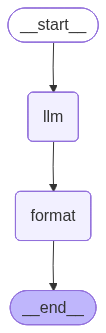

In [6]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Visualization not available: {e}")